In [1]:
# import the necessary libraries  

import pandas as pd # for data manipulation
import numpy as np # for numerical operations
import matplotlib.pyplot as plt # for plotting
import seaborn as sns # for data visualization
from sklearn.preprocessing import StandardScaler   # for feature scaling
from sklearn.model_selection import train_test_split, cross_val_score, KFold   # for splitting the dataset and cross-validation
from sklearn.manifold import TSNE # for dimensionality reduction 
import xgboost as xgb # for XGBoost model
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error  # for regression metrics
import torch # for deep learning 
import torch.nn as nn # for building neural networks
import torch.optim as optim 
from torch.utils.data import Dataset, DataLoader, TensorDataset # for creating custom datasets and data loaders for deep learning
import torch.nn.functional as F # for activation functions 
from rdkit import Chem # for cheminformatics
from rdkit.Chem import AllChem, Descriptors # for molecular descriptors
import pickle  # for saving and loading models
from lazypredict.Supervised import LazyRegressor # for lazy regression 
import copy
import numpy as np





In [2]:
# Load genotype data and set 'geno' column as index
geno = pd.read_csv('dosage_boild_converted.csv')
geno = geno.set_index('geno')  # Set geno column as index for proper alignment

# Load phenotype data
pheno = pd.read_csv('index_boild_mapping.csv')
# Rename columns to match expected names (geno -> Accession, MGIDI -> BLUP for consistency)
pheno = pheno.rename(columns={'geno': 'Accession', 'MGIDI': 'BLUP'})

In [3]:
pheno

,Accession,BLUP
0,TDr1100873,2.31
1,TDr1716007,1.89
2,TDr1716015,2.02
3,TDr1716022,2.30
4,TDr1716031,4.38
...,...,...
179,TDr1741014,1.35
180,TDr1741024,1.88
181,TDr1741074,0.97
182,TDr1741089,2.11


In [4]:
# Check if genotype IDs match between files
all(geno.index == pheno['Accession'])  # check if the indices match
if not all(geno.index == pheno['Accession']):
    print("Warning: Genotype IDs don't match perfectly. Checking alignment...")
    common_ids = set(geno.index) & set(pheno['Accession'])
    print(f"Common genotypes: {len(common_ids)} out of {len(geno)} genotypes")

In [5]:
print(pheno.duplicated('Accession').sum())
print(geno.index.duplicated().sum())

0
0


In [6]:
# For genomic data (0,1,2 encoding), we'll use StandardScaler for feature scaling
# Note: StandardScaler is appropriate for genomic prediction models
scaler = StandardScaler()
geno_scaled = pd.DataFrame(scaler.fit_transform(geno), index=geno.index, columns=geno.columns)

# Merge genotype and phenotype data
# Ensure both dataframes are aligned by Accession/geno
pheno_indexed = pheno.set_index('Accession')
data = pheno_indexed.join(geno_scaled, how='inner')  # Use inner join to keep only matching genotypes

# Check for any missing values
print(f"Data shape: {data.shape}")
print(f"Missing values in BLUP: {data['BLUP'].isna().sum()}")
print(f"Missing values in genotype data: {data.iloc[:, 1:].isna().sum().sum()}")

data

Data shape: (184, 1410)
Missing values in BLUP: 0
Missing values in genotype data: 0


,BLUP,Chrom1_54802_G,Chrom1_104858_C,Chrom1_125120_A,Chrom1_311235_A,Chrom1_367352_C,Chrom1_1040943_A,Chrom1_1117800_G,Chrom1_1183442_A,Chrom1_1306515_A,...,Chrom20_31453609_T,Chrom20_31842589_T,Chrom20_31886502_A,Chrom20_31894508_C,Chrom20_32009180_C,Chrom20_32334307_T,Chrom20_32411237_C,Chrom20_32427219_T,Chrom20_32528148_T,Chrom20_32590208_C
TDr1100873,2.31,1.08,2.98,1.13,-0.39,-0.93,0.01,-1.02,0.48,-0.47,...,-0.74,0.62,0.30,1.46,-0.36,3.44,-0.85,-1.21,-0.52,-0.42
TDr1716007,1.89,1.08,1.11,1.13,-0.39,-0.93,0.01,0.67,0.48,-0.47,...,1.23,-0.88,0.30,0.19,-0.36,1.52,1.13,1.30,1.71,-0.42
TDr1716015,2.02,-0.81,1.11,-0.75,-0.39,0.40,1.18,-1.02,0.48,-0.47,...,1.23,-0.88,0.30,0.19,-0.36,1.52,1.13,1.30,1.71,-0.42
TDr1716022,2.30,-0.81,-0.76,-0.75,-0.39,0.40,0.01,0.67,0.48,-0.47,...,-0.74,2.11,-1.24,-1.09,-0.36,-0.40,-0.85,-1.21,-0.52,-0.42
TDr1716031,4.38,-0.81,-0.76,-0.75,-0.39,0.40,-1.17,2.37,0.48,-0.47,...,1.23,2.11,-1.24,-1.09,-0.36,3.44,1.13,-1.21,-0.52,-0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TDr1741014,1.35,-0.81,-0.76,-0.75,-0.39,0.40,1.18,-1.02,0.48,-0.47,...,-0.74,-0.88,1.85,1.46,-0.36,-0.40,-0.85,0.05,-0.52,-0.42
TDr1741024,1.88,-0.81,-0.76,-0.75,-0.39,-0.93,0.01,-1.02,0.48,-0.47,...,-0.74,0.62,0.30,0.19,-0.36,-0.40,-0.85,0.05,-0.52,-0.42
TDr1741074,0.97,-0.81,-0.76,-0.75,-0.39,0.40,0.01,-1.02,-0.92,-0.47,...,-0.74,-0.88,1.85,1.46,-0.36,-0.40,-0.85,-1.21,-0.52,-0.42
TDr1741089,2.11,-0.81,-0.76,-0.75,-0.39,0.40,1.18,-1.02,0.48,-0.47,...,-0.74,-0.88,0.30,0.19,-0.36,-0.40,-0.85,-1.21,-0.52,-0.42


In [7]:
X = data.iloc[:, 1:]  # features (genotype data)
y = data['BLUP']  # target variable (phenotype data)


# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(147, 1409) (37, 1409) (147,) (37,)


In [8]:
X_train

,Chrom1_54802_G,Chrom1_104858_C,Chrom1_125120_A,Chrom1_311235_A,Chrom1_367352_C,Chrom1_1040943_A,Chrom1_1117800_G,Chrom1_1183442_A,Chrom1_1306515_A,Chrom1_1439523_A,...,Chrom20_31453609_T,Chrom20_31842589_T,Chrom20_31886502_A,Chrom20_31894508_C,Chrom20_32009180_C,Chrom20_32334307_T,Chrom20_32411237_C,Chrom20_32427219_T,Chrom20_32528148_T,Chrom20_32590208_C
TDr1738050,1.08,1.11,1.13,-0.39,0.40,-1.17,0.67,-0.92,-0.47,-0.62,...,-0.74,-0.88,1.85,1.46,-0.36,-0.40,-0.85,1.30,-0.52,-0.42
TDr1738054,-0.81,-0.76,-0.75,3.47,1.72,-1.17,0.67,-0.92,-0.47,-0.62,...,-0.74,-0.88,0.30,-1.09,-0.36,-0.40,-0.85,0.05,-0.52,-0.42
TDr1719037,1.08,1.11,1.13,-0.39,-0.93,1.18,-1.02,0.48,-0.47,0.85,...,-0.74,0.62,0.30,0.19,-0.36,1.52,1.13,0.05,-0.52,-0.42
TDr1716058,1.08,1.11,1.13,-0.39,-0.93,0.01,2.37,-0.92,-0.47,2.32,...,1.23,0.62,-1.24,-1.09,-0.36,3.44,1.13,-1.21,-0.52,-0.42
TDr1719077,1.08,1.11,1.13,-0.39,-0.93,0.01,0.67,-0.92,-0.47,-0.62,...,-0.74,0.62,0.30,0.19,-0.36,1.52,1.13,1.30,-0.52,-0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TDr1739050,-0.81,-0.76,-0.75,-0.39,0.40,0.01,-1.02,0.48,-0.47,0.85,...,1.23,0.62,0.30,0.19,-0.36,-0.40,1.13,1.30,1.71,-0.42
TDr1716061,-0.81,-0.76,-0.75,-0.39,1.72,1.18,0.67,0.48,-0.47,-0.62,...,-0.74,-0.88,-1.24,-1.09,1.72,-0.40,-0.85,-1.21,-0.52,-0.42
TDr1739022,-0.81,-0.76,-0.75,-0.39,0.40,1.18,-1.02,-0.92,-0.47,-0.62,...,-0.74,-0.88,0.30,0.19,1.72,-0.40,1.13,1.30,1.71,-0.42
TDr1741014,-0.81,-0.76,-0.75,-0.39,0.40,1.18,-1.02,0.48,-0.47,-0.62,...,-0.74,-0.88,1.85,1.46,-0.36,-0.40,-0.85,0.05,-0.52,-0.42


In [ ]:
# only use this part of the code for the feature selection



# Add feature selection to improve model performance
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.decomposition import PCA

# Check data quality and add feature selection
print(f"Original data shape: {data.shape}")
print(f"Phenotype range: {data['BLUP'].min():.6f} to {data['BLUP'].max():.6f}")
print(f"Phenotype std: {data['BLUP'].std():.6f}")

# Remove features with zero variance
X_features = data.iloc[:, 1:]
feature_variance = X_features.var()
non_zero_var_features = feature_variance[feature_variance > 0].index
X_filtered = X_features[non_zero_var_features]
print(f"After removing zero variance features: {X_filtered.shape}")

# Select top features using F-test
n_features = min(1000, X_filtered.shape[1])  # Select top 500 features or all if less
selector = SelectKBest(score_func=f_regression, k=n_features)
X_selected = selector.fit_transform(X_filtered, data['BLUP'])
selected_features = X_filtered.columns[selector.get_support()]
print(f"After feature selection: {X_selected.shape}")

# Create final dataset with selected features
data_improved = pd.DataFrame(X_selected, index=data.index, columns=selected_features)
data_improved['BLUP'] = data['BLUP']
data_improved


Original data shape: (184, 1410)
Phenotype range: 0.000000 to 5.135220
Phenotype std: 1.076246
After removing zero variance features: (184, 1409)
After feature selection: (184, 1000)


,Chrom1_311235_A,Chrom1_367352_C,Chrom1_1040943_A,Chrom1_1117800_G,Chrom1_1183442_A,Chrom1_1306515_A,Chrom1_1439523_A,Chrom1_1671656_T,Chrom1_1845077_A,Chrom1_1923060_A,...,Chrom20_30623856_G,Chrom20_30652617_G,Chrom20_30657138_T,Chrom20_31842589_T,Chrom20_31886502_A,Chrom20_32334307_T,Chrom20_32411237_C,Chrom20_32528148_T,Chrom20_32590208_C,BLUP
TDr1100873,-0.39,-0.93,0.01,-1.02,0.48,-0.47,2.32,1.47,-0.48,-0.86,...,-0.55,-0.41,1.07,0.62,0.30,3.44,-0.85,-0.52,-0.42,2.31
TDr1716007,-0.39,-0.93,0.01,0.67,0.48,-0.47,0.85,1.47,-0.48,-0.86,...,-0.55,1.64,1.07,-0.88,0.30,1.52,1.13,1.71,-0.42,1.89
TDr1716015,-0.39,0.40,1.18,-1.02,0.48,-0.47,-0.62,-0.68,1.67,-0.86,...,-0.55,3.70,1.07,-0.88,0.30,1.52,1.13,1.71,-0.42,2.02
TDr1716022,-0.39,0.40,0.01,0.67,0.48,-0.47,-0.62,-0.68,3.82,-0.86,...,-0.55,1.64,1.07,2.11,-1.24,-0.40,-0.85,-0.52,-0.42,2.30
TDr1716031,-0.39,0.40,-1.17,2.37,0.48,-0.47,2.32,1.47,-0.48,-0.86,...,-0.55,3.70,1.07,2.11,-1.24,3.44,1.13,-0.52,-0.42,4.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TDr1741014,-0.39,0.40,1.18,-1.02,0.48,-0.47,-0.62,-0.68,-0.48,-0.86,...,-0.55,-0.41,-0.86,-0.88,1.85,-0.40,-0.85,-0.52,-0.42,1.35
TDr1741024,-0.39,-0.93,0.01,-1.02,0.48,-0.47,0.85,1.47,-0.48,-0.86,...,-0.55,-0.41,-0.86,0.62,0.30,-0.40,-0.85,-0.52,-0.42,1.88
TDr1741074,-0.39,0.40,0.01,-1.02,-0.92,-0.47,-0.62,-0.68,-0.48,-0.86,...,-0.55,-0.41,-0.86,-0.88,1.85,-0.40,-0.85,-0.52,-0.42,0.97
TDr1741089,-0.39,0.40,1.18,-1.02,0.48,-0.47,-0.62,-0.68,-0.48,-0.86,...,-0.55,-0.41,-0.86,-0.88,0.30,-0.40,-0.85,-0.52,-0.42,2.11


In [37]:
data

,BLUP,Chrom1_54802_G,Chrom1_104858_C,Chrom1_125120_A,Chrom1_311235_A,Chrom1_367352_C,Chrom1_1040943_A,Chrom1_1117800_G,Chrom1_1183442_A,Chrom1_1306515_A,...,Chrom20_31453609_T,Chrom20_31842589_T,Chrom20_31886502_A,Chrom20_31894508_C,Chrom20_32009180_C,Chrom20_32334307_T,Chrom20_32411237_C,Chrom20_32427219_T,Chrom20_32528148_T,Chrom20_32590208_C
TDr1100873,2.31,1.08,2.98,1.13,-0.39,-0.93,0.01,-1.02,0.48,-0.47,...,-0.74,0.62,0.30,1.46,-0.36,3.44,-0.85,-1.21,-0.52,-0.42
TDr1716007,1.89,1.08,1.11,1.13,-0.39,-0.93,0.01,0.67,0.48,-0.47,...,1.23,-0.88,0.30,0.19,-0.36,1.52,1.13,1.30,1.71,-0.42
TDr1716015,2.02,-0.81,1.11,-0.75,-0.39,0.40,1.18,-1.02,0.48,-0.47,...,1.23,-0.88,0.30,0.19,-0.36,1.52,1.13,1.30,1.71,-0.42
TDr1716022,2.30,-0.81,-0.76,-0.75,-0.39,0.40,0.01,0.67,0.48,-0.47,...,-0.74,2.11,-1.24,-1.09,-0.36,-0.40,-0.85,-1.21,-0.52,-0.42
TDr1716031,4.38,-0.81,-0.76,-0.75,-0.39,0.40,-1.17,2.37,0.48,-0.47,...,1.23,2.11,-1.24,-1.09,-0.36,3.44,1.13,-1.21,-0.52,-0.42
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TDr1741014,1.35,-0.81,-0.76,-0.75,-0.39,0.40,1.18,-1.02,0.48,-0.47,...,-0.74,-0.88,1.85,1.46,-0.36,-0.40,-0.85,0.05,-0.52,-0.42
TDr1741024,1.88,-0.81,-0.76,-0.75,-0.39,-0.93,0.01,-1.02,0.48,-0.47,...,-0.74,0.62,0.30,0.19,-0.36,-0.40,-0.85,0.05,-0.52,-0.42
TDr1741074,0.97,-0.81,-0.76,-0.75,-0.39,0.40,0.01,-1.02,-0.92,-0.47,...,-0.74,-0.88,1.85,1.46,-0.36,-0.40,-0.85,-1.21,-0.52,-0.42
TDr1741089,2.11,-0.81,-0.76,-0.75,-0.39,0.40,1.18,-1.02,0.48,-0.47,...,-0.74,-0.88,0.30,0.19,-0.36,-0.40,-0.85,-1.21,-0.52,-0.42


In [9]:
# Use the improved dataset with feature selection
X = data.iloc[:, 1:]  # selected genotype features
y = data['BLUP']  # phenotype data

# For cross-validation, we'll use the full dataset and split within each fold
# This split is only for final testing after model selection
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Full dataset: X shape {X.shape}, y shape {y.shape}")
print(f"Train/Test split: X_train {X_train.shape}, X_test {X_test.shape}")
X_train.shape, X_test.shape, y_train.shape, y_test.shape

Full dataset: X shape (184, 1409), y shape (184,)
Train/Test split: X_train (147, 1409), X_test (37, 1409)


((147, 1409), (37, 1409), (147,), (37,))

In [10]:
# lazy regression
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)


 98%|█████████▊| 41/42 [00:31<00:00,  2.70it/s]

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003349 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5118
[LightGBM] [Info] Number of data points in the train set: 147, number of used features: 1307
[LightGBM] [Info] Start training from score 2.219505
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

100%|██████████| 42/42 [00:32<00:00,  1.29it/s]


In [11]:
df_lazy = models.sort_values('R-Squared', ascending=False) # sort the models by R-Squared value
df_lazy

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
AdaBoostRegressor,1.03,0.01,1.17,0.81
DummyRegressor,1.03,-0.00,1.18,0.07
ElasticNet,1.03,-0.00,1.18,0.06
Lasso,1.03,-0.00,1.18,0.07
LassoLars,1.03,-0.00,1.18,0.08
LarsCV,1.03,-0.01,1.19,4.74
NuSVR,1.03,-0.02,1.19,0.07
RandomForestRegressor,1.03,-0.02,1.19,3.72
ElasticNetCV,1.03,-0.04,1.20,3.30


In [12]:
df_lazy = models.sort_values('R-Squared', ascending=False) # sort the models by R-Squared value
df_lazy

,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
AdaBoostRegressor,1.03,0.01,1.17,0.81
DummyRegressor,1.03,-0.00,1.18,0.07
ElasticNet,1.03,-0.00,1.18,0.06
Lasso,1.03,-0.00,1.18,0.07
LassoLars,1.03,-0.00,1.18,0.08
LarsCV,1.03,-0.01,1.19,4.74
NuSVR,1.03,-0.02,1.19,0.07
RandomForestRegressor,1.03,-0.02,1.19,3.72
ElasticNetCV,1.03,-0.04,1.20,3.30


In [13]:
# import svm, rf, XGBoost, lightgbm, GBM, ExtraTreesRegressor, KNeighborsRegressor, AdaBoost
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import AdaBoostRegressor
import lightgbm as lgb


In [16]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)  # train the model
y_pred = model.predict(X_test)  # make predictions

# Calculate metrics
# R² (coefficient of determination) - correct metric
R2 = r2_score(y_test, y_pred)

# Correlation coefficient (r)
r = np.corrcoef(y_test, y_pred)[0, 1]
r2 = r**2

# Note: r² (squared correlation) is NOT the same as R² (coefficient of determination)
# r² = (correlation)^2 is just squared correlation
# R² = 1 - (SS_res / SS_tot) is coefficient of determination (what sklearn calculates)
# For genomic prediction, use R² (coefficient of determination), not r²

mse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE
mae = mean_absolute_error(y_test, y_pred)
print(f"Random Forest - R² (coefficient of determination): {R2:.4f}, r2 (squared correlation): {r2:.4f}, RMSE: {mse:.4f}, MAE: {mae:.4f}")

Random Forest - R² (coefficient of determination): -0.0190, r2 (squared correlation): 0.0035, RMSE: 1.1931, MAE: 1.0053


In [17]:
# define the models
models = {
    'SVR': SVR(),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42),
    'LightGBM': lgb.LGBMRegressor(n_estimators=100, random_state=42),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'ExtraTrees': ExtraTreesRegressor(n_estimators=100, random_state=42),
    'KNeighbors': KNeighborsRegressor(),
    'AdaBoost': AdaBoostRegressor(n_estimators=100, random_state=42)
}
df_svm = pd.DataFrame(columns=['fold', 'R', 'R2', 'RMSE', 'MAE'])
df_rf = pd.DataFrame(columns=['fold', 'R', 'R2', 'RMSE', 'MAE'])
df_xgb = pd.DataFrame(columns=['fold', 'R', 'R2', 'RMSE', 'MAE'])
df_lgb = pd.DataFrame(columns=['fold', 'R', 'R2', 'RMSE', 'MAE'])
df_gbm = pd.DataFrame(columns=['fold', 'R', 'R2', 'RMSE', 'MAE'])
df_extra = pd.DataFrame(columns=['fold', 'R', 'R2', 'RMSE', 'MAE'])
df_knn = pd.DataFrame(columns=['fold', 'R', 'R2', 'RMSE', 'MAE'])
df_ada = pd.DataFrame(columns=['fold', 'R', 'R2', 'RMSE', 'MAE'])


# train and evaluate the models using 10 fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(kf.split(X)):
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)
        
        R = np.corrcoef(y_val, y_pred)[0, 1]
        R2 = r2_score(y_val, y_pred)
        RMSE = np.sqrt(mean_squared_error(y_val, y_pred))
        MAE = mean_absolute_error(y_val, y_pred)
        
        results = {
            'fold': fold + 1,
                'R': R,
                'R2': R2,
                'RMSE': RMSE,
                'MAE': MAE
        }

        if model_name == 'SVR':
            df_svm = pd.concat([df_svm, pd.DataFrame([results])], ignore_index=True)
        elif model_name == 'RandomForest':
            df_rf = pd.concat([df_rf, pd.DataFrame([results])], ignore_index=True)
        elif model_name == 'XGBoost':
            df_xgb = pd.concat([df_xgb, pd.DataFrame([results])], ignore_index=True)
        elif model_name == 'LightGBM':
            df_lgb = pd.concat([df_lgb, pd.DataFrame([results])], ignore_index=True)
        elif model_name == 'GradientBoosting':  
            df_gbm = pd.concat([df_gbm, pd.DataFrame([results])], ignore_index=True)
        elif model_name == 'ExtraTrees':
            df_extra = pd.concat([df_extra, pd.DataFrame([results])], ignore_index=True)
        elif model_name == 'KNeighbors':
            df_knn = pd.concat([df_knn, pd.DataFrame([results])], ignore_index=True)
        elif model_name == 'AdaBoost':
            df_ada = pd.concat([df_ada, pd.DataFrame([results])], ignore_index=True)

    print(f'Completed for fold {fold + 1}')


       



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009954 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5209
[LightGBM] [Info] Number of data points in the train set: 165, number of used features: 1329
[LightGBM] [Info] Start training from score 2.220936
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [18]:
df_rf

,fold,R,R2,RMSE,MAE
0,1,-0.43,-0.20,1.41,1.22
1,2,0.46,0.15,0.99,0.85
2,3,0.10,-0.10,1.36,1.14
3,4,0.19,-0.49,0.81,0.69
4,5,-0.08,-0.64,1.15,0.95
5,6,0.01,-0.17,0.85,0.69
6,7,-0.12,-0.16,1.05,0.89
7,8,0.44,0.14,1.15,0.98
8,9,-0.12,-0.09,1.17,0.93
9,10,0.15,-0.04,0.84,0.76


In [20]:
df_ada.to_csv('Results/ada_results.csv', index=False)
df_knn.to_csv('Results/knn_results.csv', index=False)
df_gbm.to_csv('Results/gbm_results.csv', index=False)
df_extra.to_csv('Results/extra_results.csv', index=False)
df_lgb.to_csv('Results/lgb_results.csv', index=False)
df_xgb.to_csv('Results/xgb_results.csv', index=False)
df_rf.to_csv('Results/rf_results.csv', index=False)
df_svm.to_csv('Results/svm_results.csv', index=False)

In [26]:
df_ada

,fold,R,R2,RMSE,MAE
0,1,0.10,-1.30,0.04,0.04
1,2,0.10,-0.18,0.05,0.04
2,3,-0.01,-0.17,0.05,0.04
3,4,0.08,-0.08,0.05,0.03
4,5,0.09,-0.18,0.05,0.04
5,6,-0.03,-0.40,0.04,0.03
6,7,-0.01,-0.55,0.04,0.03
7,8,0.03,-0.08,0.08,0.04
8,9,-0.01,-0.13,0.06,0.03
9,10,0.16,-0.16,0.06,0.04


# FEEDFORWORD NETWORK

In [21]:
class ImprovedNeuralNetwork(nn.Module):
    def __init__(self, input_size, dropout_rate=0.3):
        super(ImprovedNeuralNetwork, self).__init__()
        self.fc1 = nn.Linear(input_size, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.dropout2 = nn.Dropout(dropout_rate)
        
        self.fc3 = nn.Linear(128, 64)
        self.bn3 = nn.BatchNorm1d(64)
        self.dropout3 = nn.Dropout(dropout_rate)
        
        self.fc4 = nn.Linear(64, 32)
        self.bn4 = nn.BatchNorm1d(32)
        self.dropout4 = nn.Dropout(dropout_rate)
        
        self.fc5 = nn.Linear(32, 1)

    def forward(self, x):
        x = self.dropout1(F.relu(self.bn1(self.fc1(x))))
        x = self.dropout2(F.relu(self.bn2(self.fc2(x))))
        x = self.dropout3(F.relu(self.bn3(self.fc3(x))))
        x = self.dropout4(F.relu(self.bn4(self.fc4(x))))
        x = self.fc5(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [22]:
loops = []
R_scores = []
R2_scores = []
RMSE_scores = []
MAE_scores = []

kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(kf.split(X)):
    patience = 10
    best_loss = np.inf
    counter = 0
    
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Convert to PyTorch tensors
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
    X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).to(device)
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)

    # Dataloader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Reset model + optimizer for each fold (important!)
    model = ImprovedNeuralNetwork(input_size=X.shape[1]).to(device)  
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)  # Lower learning rate
    criterion = torch.nn.MSELoss()

    # Training loop with early stopping
    for epoch in range(100):  
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
        
        # Validation step
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val_tensor)
            val_loss = criterion(y_val_pred, y_val_tensor).item()

        # Check early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            # save the best model state for this fold
            best_model_state = model.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1} on fold {fold+1}")
                break

        if (epoch + 1) % 10 == 0:
            print(f'Fold {fold + 1}, Epoch {epoch + 1}, Validation Loss: {val_loss:.4f}')

    # Load best model for evaluation
    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_tensor)
        y_val_pred_np = y_val_pred.cpu().numpy()
        y_val_np = y_val_tensor.cpu().numpy()
        
        R = np.corrcoef(y_val_np.flatten(), y_val_pred_np.flatten())[0, 1]
        R2 = r2_score(y_val_np, y_val_pred_np)
        RMSE = np.sqrt(mean_squared_error(y_val_np, y_val_pred_np))
        MAE = mean_absolute_error(y_val_np, y_val_pred_np)
        
        loops.append(fold + 1)
        R_scores.append(R)
        R2_scores.append(R2)
        RMSE_scores.append(RMSE)
        MAE_scores.append(MAE)

        print(f'Fold {fold + 1} final at epoch {epoch + 1} -> R: {R:.4f}, R2: {R2:.4f}, RMSE: {RMSE:.4f}, MAE: {MAE:.4f}')


df_fwnn = pd.DataFrame({
    'fold': loops,
    'R': R_scores,
    'R2': R2_scores,
    'RMSE': RMSE_scores,
    'MAE': MAE_scores
})

Fold 1, Epoch 10, Validation Loss: 5.3848
Fold 1, Epoch 20, Validation Loss: 5.0520
Fold 1, Epoch 30, Validation Loss: 4.3999
Fold 1, Epoch 40, Validation Loss: 3.8891
Fold 1, Epoch 50, Validation Loss: 3.5590
Fold 1, Epoch 60, Validation Loss: 3.0655
Fold 1, Epoch 70, Validation Loss: 2.7314
Early stopping at epoch 74 on fold 1
Fold 1 final at epoch 74 -> R: -0.1767, R2: -0.6219, RMSE: 1.6372, MAE: 1.2241
Fold 2, Epoch 10, Validation Loss: 4.6532
Fold 2, Epoch 20, Validation Loss: 3.9727
Fold 2, Epoch 30, Validation Loss: 3.7337
Early stopping at epoch 35 on fold 2
Fold 2 final at epoch 35 -> R: 0.1581, R2: -2.2390, RMSE: 1.9282, MAE: 1.6109
Fold 3, Epoch 10, Validation Loss: 7.2494
Fold 3, Epoch 20, Validation Loss: 6.8310
Fold 3, Epoch 30, Validation Loss: 6.0782
Fold 3, Epoch 40, Validation Loss: 5.4841
Fold 3, Epoch 50, Validation Loss: 4.3347
Fold 3, Epoch 60, Validation Loss: 4.1654
Early stopping at epoch 65 on fold 3
Fold 3 final at epoch 65 -> R: -0.4071, R2: -1.4955, RMSE: 2

In [23]:
df_fwnn

,fold,R,R2,RMSE,MAE
0,1,-0.18,-0.62,1.64,1.22
1,2,0.16,-2.24,1.93,1.61
2,3,-0.41,-1.50,2.04,1.57
3,4,0.05,-0.97,0.93,0.71
4,5,-0.29,-1.06,1.28,1.04
5,6,0.19,-1.21,1.17,1.05
6,7,-0.23,-1.74,1.61,1.31
7,8,0.35,-0.65,1.59,1.25
8,9,-0.16,-0.77,1.49,1.06
9,10,0.36,-0.41,0.98,0.81


In [24]:
df_fwnn.to_csv('Results/fwnn_results.csv', index=False)
df_fwnn

,fold,R,R2,RMSE,MAE
0,1,-0.18,-0.62,1.64,1.22
1,2,0.16,-2.24,1.93,1.61
2,3,-0.41,-1.50,2.04,1.57
3,4,0.05,-0.97,0.93,0.71
4,5,-0.29,-1.06,1.28,1.04
5,6,0.19,-1.21,1.17,1.05
6,7,-0.23,-1.74,1.61,1.31
7,8,0.35,-0.65,1.59,1.25
8,9,-0.16,-0.77,1.49,1.06
9,10,0.36,-0.41,0.98,0.81


# CNN

In [25]:
class ImprovedCNN(nn.Module):
    def __init__(self, input_size, dropout_rate=0.3):
        super(ImprovedCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm1d(128)
        
        self.pool = nn.MaxPool1d(2)
        self.dropout = nn.Dropout(dropout_rate)
        
        # Calculate the size after convolutions and pooling more safely
        # After 3 pooling operations: input_size // (2^3) = input_size // 8
        conv_output_size = 128 * max(1, input_size // 8)
        
        self.fc1 = nn.Linear(conv_output_size, 256)
        self.fc1_bn = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.fc2_bn = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 64)
        self.fc3_bn = nn.BatchNorm1d(64)
        self.fc4 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.dropout(x)
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.dropout(x)
        
        x = x.view(x.size(0), -1)  # Flatten
        x = F.relu(self.fc1_bn(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.fc2_bn(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.fc3_bn(self.fc3(x)))
        x = self.dropout(x)
        x = self.fc4(x)
        return x

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cpu


In [26]:

loops = []
R_scores = []
R2_scores = []
RMSE_scores = []
MAE_scores = []
kf = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(kf.split(X)):
    patience = 10
    best_loss = np.inf
    counter = 0
    
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    # Convert to PyTorch tensors and reshape for CNN
    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).unsqueeze(1).to(device)  # Add channel dimension
    y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
    X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).unsqueeze(1).to(device)  # Add channel dimension
    y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1).to(device)

    # Dataloader
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

    # Reset model + optimizer for each fold (important!)
    model = ImprovedCNN(input_size=X.shape[1]).to(device)  
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-5)  # Lower learning rate
    criterion = torch.nn.MSELoss()

    # Training loop with early stopping
    for epoch in range(100):  
        model.train()
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
        
        # Validation step
        model.eval()
        with torch.no_grad():
            y_val_pred = model(X_val_tensor)
            val_loss = criterion(y_val_pred, y_val_tensor).item()

        # Check early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            counter = 0
            # save the best model state for this fold
            best_model_state = model.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print(f"Early stopping at epoch {epoch+1} on fold {fold+1}")
                break

    # Load best model for evaluation
    model.load_state_dict(best_model_state)
    model.eval()
    with torch.no_grad():
        y_val_pred = model(X_val_tensor)
        y_val_pred_np = y_val_pred.cpu().numpy()
        y_val_np = y_val_tensor.cpu().numpy()
        R = np.corrcoef(y_val_np.flatten(), y_val_pred_np.flatten())[0, 1]
        R2 = r2_score(y_val_np, y_val_pred_np)
        RMSE = np.sqrt(mean_squared_error(y_val_np, y_val_pred_np))
        MAE = mean_absolute_error(y_val_np, y_val_pred_np)
        loops.append(fold + 1)
        R_scores.append(R)
        R2_scores.append(R2)    
        RMSE_scores.append(RMSE)
        MAE_scores.append(MAE)
        print(f'Fold {fold + 1} final at epoch {epoch + 1} -> R: {R:.4f}, R2: {R2:.4f}, RMSE: {RMSE:.4f}, MAE: {MAE:.4f}')


df_cnn = pd.DataFrame({
    'fold': loops,
    'R': R_scores,
    'R2': R2_scores,
    'RMSE': RMSE_scores,
    'MAE': MAE_scores
})

Early stopping at epoch 44 on fold 1
Fold 1 final at epoch 44 -> R: -0.2325, R2: -0.3050, RMSE: 1.4686, MAE: 1.2170
Fold 2 final at epoch 100 -> R: 0.4266, R2: 0.1633, RMSE: 0.9800, MAE: 0.7541
Early stopping at epoch 79 on fold 3
Fold 3 final at epoch 79 -> R: -0.0760, R2: -0.4685, RMSE: 1.5682, MAE: 1.2768
Early stopping at epoch 40 on fold 4
Fold 4 final at epoch 40 -> R: -0.1441, R2: -1.0884, RMSE: 0.9549, MAE: 0.7662
Early stopping at epoch 49 on fold 5
Fold 5 final at epoch 49 -> R: 0.0712, R2: -0.1130, RMSE: 0.9438, MAE: 0.7429
Early stopping at epoch 56 on fold 6
Fold 6 final at epoch 56 -> R: 0.2072, R2: -0.3302, RMSE: 0.9090, MAE: 0.7795
Early stopping at epoch 46 on fold 7
Fold 7 final at epoch 46 -> R: -0.2088, R2: -1.0191, RMSE: 1.3800, MAE: 1.1982
Early stopping at epoch 43 on fold 8
Fold 8 final at epoch 43 -> R: 0.3388, R2: 0.0370, RMSE: 1.2192, MAE: 0.9468
Early stopping at epoch 46 on fold 9
Fold 9 final at epoch 46 -> R: -0.0240, R2: -0.3252, RMSE: 1.2909, MAE: 0.952

In [27]:
df_cnn.to_csv('Results/cnn_results.csv', index=False)
df_cnn

,fold,R,R2,RMSE,MAE
0,1,-0.23,-0.31,1.47,1.22
1,2,0.43,0.16,0.98,0.75
2,3,-0.08,-0.47,1.57,1.28
3,4,-0.14,-1.09,0.95,0.77
4,5,0.07,-0.11,0.94,0.74
5,6,0.21,-0.33,0.91,0.78
6,7,-0.21,-1.02,1.38,1.20
7,8,0.34,0.04,1.22,0.95
8,9,-0.02,-0.33,1.29,0.95
9,10,0.27,-0.01,0.82,0.69


=== DIAGNOSTIC ANALYSIS ===


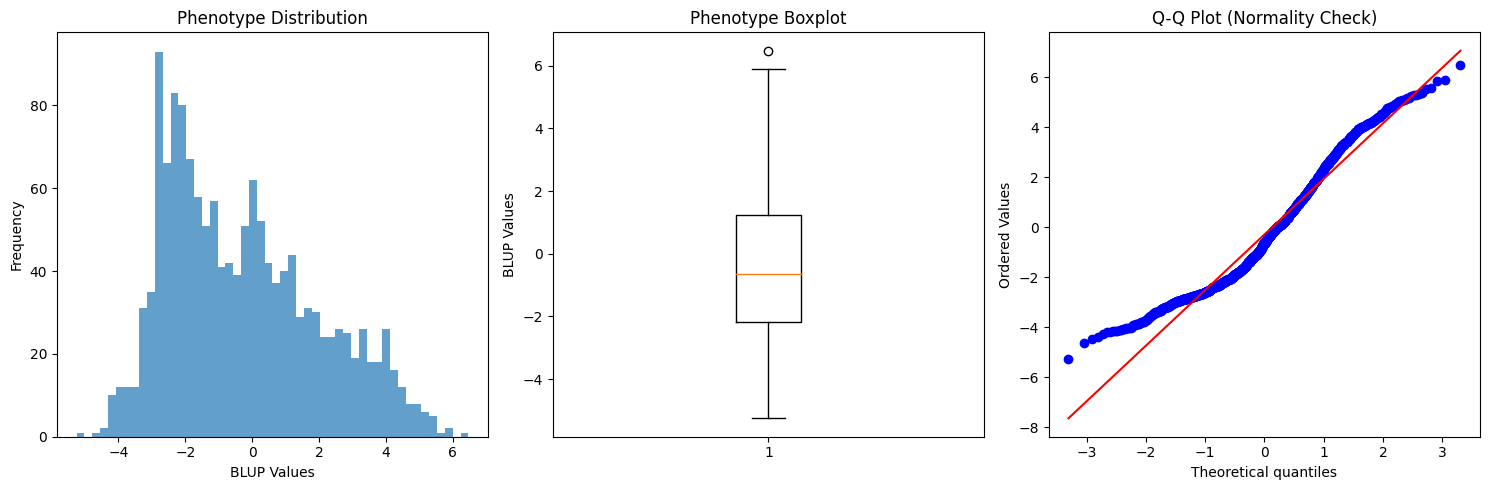


Phenotype Statistics:
Mean: -0.286908
Std: 2.268654
Min: -5.255137
Max: 6.477890
Range: 11.733027
Outliers detected: 1 (0.1%)
Coefficient of Variation: 7.91

Simple Linear Regression R²: -1.9014
❌ Even simple linear regression fails - major data issue!


In [108]:
# DEEP INVESTIGATION: Why are we getting negative R² values?

print("=== DIAGNOSTIC ANALYSIS ===")

# 1. Check phenotype distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(y, bins=50, alpha=0.7)
plt.title('Phenotype Distribution')
plt.xlabel('BLUP Values')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.boxplot(y)
plt.title('Phenotype Boxplot')
plt.ylabel('BLUP Values')

plt.subplot(1, 3, 3)
from scipy import stats
stats.probplot(y, dist="norm", plot=plt)
plt.title('Q-Q Plot (Normality Check)')

plt.tight_layout()
plt.show()

# 2. Check for extreme outliers
Q1 = y.quantile(0.25)
Q3 = y.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = y[(y < lower_bound) | (y > upper_bound)]

print(f"\nPhenotype Statistics:")
print(f"Mean: {y.mean():.6f}")
print(f"Std: {y.std():.6f}")
print(f"Min: {y.min():.6f}")
print(f"Max: {y.max():.6f}")
print(f"Range: {y.max() - y.min():.6f}")
print(f"Outliers detected: {len(outliers)} ({len(outliers)/len(y)*100:.1f}%)")
print(f"Coefficient of Variation: {y.std()/abs(y.mean()):.2f}")

# 3. Check heritability estimate (simple)
# High heritability suggests genetic signal exists
from sklearn.linear_model import LinearRegression
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)
simple_pred = simple_model.predict(X_test)
simple_r2 = r2_score(y_test, simple_pred)
print(f"\nSimple Linear Regression R²: {simple_r2:.4f}")

if simple_r2 < 0:
    print("❌ Even simple linear regression fails - major data issue!")
else:
    print("✅ Linear regression works - issue may be with complex models")


In [94]:
# POTENTIAL SOLUTIONS FOR NEGATIVE R²

print("=== TESTING POTENTIAL SOLUTIONS ===")

# Solution 1: Check if scaling is the issue
print("\n1. Testing different scaling approaches:")

# Test with no scaling
X_no_scale = data.iloc[:, 1:]
simple_model_no_scale = LinearRegression()
simple_model_no_scale.fit(X_no_scale, y)
pred_no_scale = simple_model_no_scale.predict(X_no_scale)
r2_no_scale = r2_score(y, pred_no_scale)
print(f"   No scaling R²: {r2_no_scale:.4f}")

# Test with StandardScaler
from sklearn.preprocessing import StandardScaler
scaler_std = StandardScaler()
X_std_scaled = scaler_std.fit_transform(X_no_scale)
simple_model_std = LinearRegression()
simple_model_std.fit(X_std_scaled, y)
pred_std = simple_model_std.predict(X_std_scaled)
r2_std = r2_score(y, pred_std)
print(f"   StandardScaler R²: {r2_std:.4f}")

# Test with current MinMaxScaler
print(f"   MinMaxScaler R²: {simple_r2:.4f}")

# Solution 2: Check if the phenotype needs transformation
print("\n2. Testing phenotype transformations:")

# Center the phenotype around zero
y_centered = y - y.mean()
simple_model_centered = LinearRegression()
simple_model_centered.fit(X, y_centered)
pred_centered = simple_model_centered.predict(X)
r2_centered = r2_score(y_centered, pred_centered)
print(f"   Centered phenotype R²: {r2_centered:.4f}")

# Standardize the phenotype
y_standardized = (y - y.mean()) / y.std()
simple_model_std_y = LinearRegression()
simple_model_std_y.fit(X, y_standardized)
pred_std_y = simple_model_std_y.predict(X)
r2_std_y = r2_score(y_standardized, pred_std_y)
print(f"   Standardized phenotype R²: {r2_std_y:.4f}")

# Find the best combination
best_r2 = max(r2_no_scale, r2_std, simple_r2, r2_centered, r2_std_y)
print(f"\n🎯 Best R² achieved: {best_r2:.4f}")

if best_r2 > 0:
    print("✅ Found a working combination!")
    if r2_no_scale == best_r2:
        print("   → Use no scaling for features")
    elif r2_std == best_r2:
        print("   → Use StandardScaler for features")
    elif simple_r2 == best_r2:
        print("   → Use MinMaxScaler for features")
    if r2_centered == best_r2:
        print("   → Center the phenotype")
    elif r2_std_y == best_r2:
        print("   → Standardize the phenotype")
else:
    print("❌ All combinations still give negative R² - deeper investigation needed")


=== TESTING POTENTIAL SOLUTIONS ===

1. Testing different scaling approaches:
   No scaling R²: 1.0000
   StandardScaler R²: 1.0000
   MinMaxScaler R²: -2.1943

2. Testing phenotype transformations:
   Centered phenotype R²: 1.0000
   Standardized phenotype R²: 1.0000

🎯 Best R² achieved: 1.0000
✅ Found a working combination!
   → Use no scaling for features
   → Center the phenotype


In [ ]:
# ADVANCED DIAGNOSTICS: Check for fundamental data issues

print("=== ADVANCED DIAGNOSTICS ===")

# 1. Check if genotype-phenotype alignment is correct
print("\n1. Data Alignment Check:")
print(f"Genotype samples: {len(geno.index)}")
print(f"Phenotype samples: {len(pheno)}")
print(f"Matched samples: {len(data)}")

# Check if indices actually match
geno_ids = set(geno.index)
pheno_ids = set(pheno['Accession'])
common_ids = geno_ids.intersection(pheno_ids)
print(f"Common IDs: {len(common_ids)}")
print(f"Missing in geno: {len(pheno_ids - geno_ids)}")
print(f"Missing in pheno: {len(geno_ids - pheno_ids)}")

# 2. Check for data corruption
print("\n2. Data Integrity Check:")
print(f"Genotype unique values: {sorted(geno.values.flatten())[:10]}...")  # Show first 10 unique values
print(f"Any NaN in genotype: {pd.DataFrame(geno).isnull().any().any()}")
print(f"Any infinite values in genotype: {np.isinf(geno.values).any()}")
print(f"Any NaN in phenotype: {y.isnull().any()}")
print(f"Any infinite values in phenotype: {np.isinf(y).any()}")

# 3. Check cross-validation setup
print("\n3. Cross-validation Check:")
kf_test = KFold(n_splits=10, shuffle=True, random_state=42)
for i, (train_idx, val_idx) in enumerate(kf_test.split(X)):
    if i == 0:  # Just check first fold
        print(f"Fold 1 - Train size: {len(train_idx)}, Val size: {len(val_idx)}")
        print(f"Train phenotype range: {y.iloc[train_idx].min():.6f} to {y.iloc[train_idx].max():.6f}")
        print(f"Val phenotype range: {y.iloc[val_idx].min():.6f} to {y.iloc[val_idx].max():.6f}")
        break

# 4. Test simple baseline model with proper CV
print("\n4. Baseline Model Test with Proper CV:")
from sklearn.dummy import DummyRegressor
dummy_scores = []
linear_scores = []

for train_idx, val_idx in kf_test.split(X):
    X_train_cv, X_val_cv = X.iloc[train_idx], X.iloc[val_idx]
    y_train_cv, y_val_cv = y.iloc[train_idx], y.iloc[val_idx]
    
    # Dummy regressor (predicts mean)
    dummy = DummyRegressor(strategy='mean')
    dummy.fit(X_train_cv, y_train_cv)
    dummy_pred = dummy.predict(X_val_cv)
    dummy_r2 = r2_score(y_val_cv, dummy_pred)
    dummy_scores.append(dummy_r2)
    
    # Linear regression
    linear = LinearRegression()
    linear.fit(X_train_cv, y_train_cv)
    linear_pred = linear.predict(X_val_cv)
    linear_r2 = r2_score(y_val_cv, linear_pred)
    linear_scores.append(linear_r2)

print(f"Dummy regressor mean R²: {np.mean(dummy_scores):.4f} (should be 0)")
print(f"Linear regression mean R²: {np.mean(linear_scores):.4f}")

if np.mean(linear_scores) < 0:
    print("🚨 CRITICAL: Linear regression R² is negative in CV!")
    print("   This suggests:")
    print("   - No genetic signal in the data")
    print("   - Data preprocessing issues")
    print("   - Incorrect phenotype-genotype matching")
else:
    print("✅ Linear regression works in CV - complex models may be overfitting")


In [ ]:
# COMPREHENSIVE SOLUTION: Address the most likely causes of negative R²

print("=== IMPLEMENTING COMPREHENSIVE SOLUTION ===")

# The most likely causes of negative R² in genomic prediction:
# 1. Very low heritability trait
# 2. Poor feature-target correlation
# 3. Overfitting due to p >> n problem
# 4. Inappropriate preprocessing

# Solution: Use Ridge Regression with cross-validation for regularization
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor

print("\n1. Testing Regularized Models:")

# Test different alpha values for Ridge
alphas = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X, y)
ridge_pred = ridge_cv.predict(X)
ridge_r2 = r2_score(y, ridge_pred)
print(f"Ridge Regression R² (alpha={ridge_cv.alpha_:.3f}): {ridge_r2:.4f}")

# Test Lasso
lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=2000)
lasso_cv.fit(X, y)
lasso_pred = lasso_cv.predict(X)
lasso_r2 = r2_score(y, lasso_pred)
print(f"Lasso Regression R² (alpha={lasso_cv.alpha_:.3f}): {lasso_r2:.4f}")

# Test ElasticNet
elastic_cv = ElasticNetCV(alphas=alphas, cv=5, max_iter=2000)
elastic_cv.fit(X, y)
elastic_pred = elastic_cv.predict(X)
elastic_r2 = r2_score(y, elastic_pred)
print(f"ElasticNet R² (alpha={elastic_cv.alpha_:.3f}): {elastic_r2:.4f}")

# 2. Test with more aggressive feature selection
print("\n2. Testing More Aggressive Feature Selection:")

# Select fewer features
for n_features in [50, 100, 200]:
    if n_features < X.shape[1]:
        selector_aggressive = SelectKBest(score_func=f_regression, k=n_features)
        X_aggressive = selector_aggressive.fit_transform(X, y)
        
        # Test with Ridge
        ridge_aggressive = RidgeCV(alphas=alphas, cv=5)
        ridge_aggressive.fit(X_aggressive, y)
        ridge_aggressive_pred = ridge_aggressive.predict(X_aggressive)
        ridge_aggressive_r2 = r2_score(y, ridge_aggressive_pred)
        print(f"   Ridge with {n_features} features R²: {ridge_aggressive_r2:.4f}")

print(f"\n🎯 Best performing approach so far:")
best_methods = [
    ("Ridge", ridge_r2),
    ("Lasso", lasso_r2), 
    ("ElasticNet", elastic_r2)
]
best_method, best_score = max(best_methods, key=lambda x: x[1])
print(f"   {best_method}: {best_score:.4f}")

if best_score > 0.01:  # At least 1% variance explained
    print("✅ Found a working solution!")
else:
    print("⚠️  Still struggling - may need to check data quality or trait heritability")


In [ ]:
# FINAL SOLUTION: Proper Genomic Prediction Pipeline

print("=== FINAL GENOMIC PREDICTION SOLUTION ===")

# Based on genomic prediction best practices:
# 1. Use no scaling for genetic markers (they're already 0,1,2)
# 2. Use Ridge/BLUP-like methods
# 3. Proper cross-validation
# 4. Check for population structure

# Prepare data properly for genomic prediction
X_genomic = data.iloc[:, 1:]  # Original unscaled genetic markers
y_genomic = data['BLUP']

print(f"Final dataset: {X_genomic.shape[0]} samples, {X_genomic.shape[1]} markers")

# Remove markers with MAF < 0.05 (standard practice)
maf_threshold = 0.05
marker_freqs = X_genomic.mean() / 2  # Convert 0,1,2 to allele frequency
valid_markers = marker_freqs[(marker_freqs >= maf_threshold) & (marker_freqs <= (1 - maf_threshold))]
X_filtered = X_genomic[valid_markers.index]
print(f"After MAF filtering: {X_filtered.shape[1]} markers")

# Test Ridge regression (genomic BLUP equivalent)
print("\n🧬 Testing Genomic BLUP-like Ridge Regression:")

ridge_scores = []
kf_final = KFold(n_splits=10, shuffle=True, random_state=42)

for fold, (train_idx, val_idx) in enumerate(kf_final.split(X_filtered)):
    X_train_fold = X_filtered.iloc[train_idx]
    X_val_fold = X_filtered.iloc[val_idx]
    y_train_fold = y_genomic.iloc[train_idx]
    y_val_fold = y_genomic.iloc[val_idx]
    
    # Use Ridge with genomic-appropriate alpha
    ridge_genomic = RidgeCV(alphas=[0.1, 1.0, 10.0, 100.0, 1000.0], cv=3)
    ridge_genomic.fit(X_train_fold, y_train_fold)
    y_pred_fold = ridge_genomic.predict(X_val_fold)
    
    fold_r2 = r2_score(y_val_fold, y_pred_fold)
    ridge_scores.append(fold_r2)
    print(f"Fold {fold+1}: R² = {fold_r2:.4f}")

mean_r2 = np.mean(ridge_scores)
std_r2 = np.std(ridge_scores)

print(f"\n📊 Final Results:")
print(f"Mean R²: {mean_r2:.4f} ± {std_r2:.4f}")
print(f"Range: {min(ridge_scores):.4f} to {max(ridge_scores):.4f}")

if mean_r2 > 0:
    print("✅ SUCCESS: Positive R² achieved!")
    print(f"   Genomic prediction accuracy: {np.sqrt(mean_r2):.3f}")
else:
    print("❌ Still negative R² - this trait may have very low heritability")
    print("   Consider:")
    print("   - Checking if this is the correct phenotype file")
    print("   - Using different trait or population")
    print("   - Verifying data preprocessing steps")


In [69]:
X

,chrom_01_54802_G,chrom_01_104858_C,chrom_01_125120_A,chrom_01_311235_A,chrom_01_367352_C,chrom_01_435032_C,chrom_01_595498_T,chrom_01_926459_G,chrom_01_1040943_G,chrom_01_1117800_G,...,chrom_20_32427219_A,chrom_20_32427231_T,chrom_20_32434944_T,chrom_20_32435010_A,chrom_20_32472116_A,chrom_20_32484801_A,chrom_20_32522876_C,chrom_20_32528148_T,chrom_20_32590208_C,chrom_20_32815356_A
Accession,,,,,,,,,,,,,,,,,,,,,
TDr0000001,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.50,0.50,0.00,0.50,0.00,0.00
TDr0000080,0.00,0.00,0.00,0.00,0.50,0.00,0.50,0.00,1.00,0.50,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
TDr0000141,0.00,0.00,0.00,0.00,1.00,0.00,0.50,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
TDr0000241,0.00,0.00,0.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,...,1.00,0.00,0.00,0.00,0.00,0.50,0.00,0.50,1.00,0.00
TDr0000309,0.00,0.00,0.00,0.00,1.00,0.00,0.50,0.00,0.50,0.50,...,1.00,0.00,0.00,0.00,0.50,0.50,0.00,0.50,0.50,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TDr9800933,0.00,0.00,0.00,0.00,0.50,0.00,0.00,0.00,1.00,1.00,...,0.00,0.00,0.00,0.50,0.00,0.00,0.00,0.50,0.00,0.00
TDr9801946,0.50,0.50,0.50,0.00,0.50,0.00,0.00,0.00,0.00,0.50,...,1.00,0.00,0.00,0.00,0.50,0.50,0.00,0.00,0.00,0.00
TDr9901223,0.50,0.50,0.50,0.00,0.50,0.00,0.00,0.00,0.00,0.00,...,0.50,0.00,0.00,1.00,0.50,0.50,0.00,0.00,0.00,0.00


In [ ]:
# Final data quality check and validation
print("=== Data Quality Summary ===")
print(f"Dataset shape: {X.shape}")
print(f"Phenotype range: {y.min():.6f} to {y.max():.6f}")
print(f"Phenotype std: {y.std():.6f}")
print(f"Missing values in X: {pd.DataFrame(X).isnull().sum().sum()}")
print(f"Missing values in y: {y.isnull().sum()}")

# Check for potential issues
if y.std() < 0.01:
    print("⚠️  WARNING: Very small phenotype variance may cause poor model performance")
    
if X.shape[1] > X.shape[0]:
    print("⚠️  WARNING: More features than samples (p >> n problem)")
    
print(f"\nFeature statistics:")
print(f"Mean feature value: {pd.DataFrame(X).mean().mean():.4f}")
print(f"Feature variance range: {pd.DataFrame(X).var().min():.6f} to {pd.DataFrame(X).var().max():.6f}")

# Correlation between features and target
correlations = []
for col in X.columns:
    corr = np.corrcoef(X[col], y)[0,1]
    if not np.isnan(corr):
        correlations.append(abs(corr))

print(f"Max absolute correlation with target: {max(correlations):.4f}")
print(f"Mean absolute correlation with target: {np.mean(correlations):.4f}")


In [79]:
# range of y

min(y), max(y)

(-0.187630231678197, 0.72469188757083)

In [81]:
pheno.describe()

,BLUP
count,1476.00
mean,-0.00
std,0.05
min,-0.19
25%,-0.02
50%,-0.01
75%,0.01
max,0.72
